# 신용카드 고객 이탈 예측 프로젝트
##  분류 모델링 
데이터: `bankchurners_clean.csv`

목표: 로지스틱 회귀 / Random Forest / XGBoost **3개 모델을 기본 파라미터로만** 비교 (튜닝 없음)

## 0. 라이브러리 & 데이터 로드

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/processed/bankchurners_clean.csv")
df.shape

(10127, 20)

In [3]:
df.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Target
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


## 1. 피처/타겟 분리 및 인코딩
- 범주형 변수는 원-핫 인코딩
- 수치형 변수는 그대로 사용 (트리 모델은 스케일링 불필요, 로지스틱 회귀만 별도 스케일링 적용)

In [4]:
X = df.drop(columns=["Target"])
y = df["Target"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
print("범주형 컬럼:", cat_cols)

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("인코딩 후 shape:", X.shape)

범주형 컬럼: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
인코딩 후 shape: (10127, 32)


C:\Users\UK\AppData\Local\Temp\ipykernel_19612\1829402498.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


In [5]:
X

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,45,3,39,5,1,3,12691.0,777,11914.0,1.335,...,False,False,False,True,False,False,False,False,False,False
1,49,5,44,6,1,2,8256.0,864,7392.0,1.541,...,True,False,False,False,False,True,False,False,False,False
2,51,3,36,4,1,0,3418.0,0,3418.0,2.594,...,False,False,False,False,True,False,False,False,False,False
3,40,4,34,3,4,1,3313.0,2517,796.0,1.405,...,False,True,False,False,False,True,False,False,False,False
4,40,3,21,5,1,0,4716.0,0,4716.0,2.175,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,2,40,3,2,3,4003.0,1851,2152.0,0.703,...,True,False,True,False,False,False,False,False,False,False
10123,41,2,25,4,2,3,4277.0,2186,2091.0,0.804,...,False,False,True,False,False,False,False,False,False,False
10124,44,1,36,5,3,4,5409.0,0,5409.0,0.819,...,False,False,False,False,False,True,False,False,False,False
10125,30,2,36,4,3,3,5281.0,0,5281.0,0.535,...,False,True,True,False,False,False,False,False,False,False


## 2. Train/Test 분할 (Stratify로 이탈 비율 유지)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train 이탈률: {:.1f}%".format(y_train.mean() * 100))
print("Test 이탈률: {:.1f}%".format(y_test.mean() * 100))

Train: (8101, 32) Test: (2026, 32)
Train 이탈률: 16.1%
Test 이탈률: 16.0%


## 3. — 로지스틱 회귀 
StandardScaler 적용

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)    # class_weight="balanced": 소수 클래스(이탈)를 더 신경 써서 학습
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]  # predict_proba :  단순 1,0 이진분류를 확률로 나타내는것 인덱스 0: 유지일 확률 인덱스 1: 이탈일 확률

## 4.  — Random Forest 

In [8]:
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

## 5.  — XGBoost 

In [9]:
# 불균형 비율 반영 (scale_pos_weight = 음성/양성 비율)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200, eval_metric="logloss",
    scale_pos_weight=scale_pos_weight, random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

### predict_proba 설명

## 1. 로지스틱 회귀 — 원래부터 확률을 계산하는 모델

로지스틱 회귀는 이름은 "회귀"지만 사실 확률을 예측하는 공식 자체가 내장되어 있음.

```
확률 = 1 / (1 + e^(-(β0 + β1·x1 + β2·x2 + ... )))
```

- 각 변수(거래건수, 문의횟수 등)에 가중치(β)를 곱해서 더한 값을 **시그모이드 함수**라는 S자 곡선에 통과
- 이 함수는 **어떤 숫자를 넣어도 결과가 항상 0~1 사이**로 나오게 만들어주는 수학적 트릭.
- 그래서 로지스틱 회귀는 원래부터 "확률"을 계산하고, 그 확률이 0.5 이상이면 "1(이탈)", 미만이면 "0(유지)"으로 최종 결정

## 2. Random Forest — "투표 비율"을 확률로 사용

Random Forest는 수백 개의 작은 결정트리(if-then 규칙 나무).

- 예를 들어 트리가 200개 있다고 하면, 새로운 고객이 들어왔을 때 **각 트리가 독립적으로 "이탈(1)" 또는 "유지(0)"를 투표**
- 200개 트리 중 **150개가 "이탈"이라고 투표했다면 → 확률 = 150/200 = 0.75(75%)**
- 이렇게 "전체 트리 중 몇 %가 이탈이라고 판단했는지"를 확률처럼 사용

## 3. XGBoost — 여러 트리의 점수를 합산해서 확률로 변환

XGBoost도 여러 개의 트리를 순차적으로 만드는데:
- 각 트리가 "이 고객은 이탈 쪽으로 얼마나 더 기우는가"에 대한 점수(로그오즈, log-odds)를 조금씩 더함.
- 모든 트리의 점수를 다 더한 최종값을 로지스틱 회귀와 똑같은 **시그모이드 함수**에 통과시켜서 0~1 사이 확률로 변환


## 6. 모델 성능 비교

In [13]:
def evaluate(model_name, y_train_true, y_train_pred, y_train_proba,
             y_test_true, y_test_pred, y_test_proba):
    return {
        "Model": model_name,
        "Train_F1": f1_score(y_train_true, y_train_pred),
        "Test_F1": f1_score(y_test_true, y_test_pred),
        "Train_ROC-AUC": roc_auc_score(y_train_true, y_train_proba),
        "Test_ROC-AUC": roc_auc_score(y_test_true, y_test_proba),
        "Test_Precision": precision_score(y_test_true, y_test_pred),
        "Test_Recall": recall_score(y_test_true, y_test_pred),
    }

y_train_pred_lr = lr.predict(X_train_scaled)
y_train_proba_lr = lr.predict_proba(X_train_scaled)[:, 1]

y_train_pred_rf = rf.predict(X_train)
y_train_proba_rf = rf.predict_proba(X_train)[:, 1]

y_train_pred_xgb = xgb.predict(X_train)
y_train_proba_xgb = xgb.predict_proba(X_train)[:, 1]

results = pd.DataFrame([
    evaluate("Logistic Regression", y_train, y_train_pred_lr, y_train_proba_lr,
             y_test, y_pred_lr, y_proba_lr),
    evaluate("Random Forest", y_train, y_train_pred_rf, y_train_proba_rf,
             y_test, y_pred_rf, y_proba_rf),
    evaluate("XGBoost", y_train, y_train_pred_xgb, y_train_proba_xgb,
             y_test, y_pred_xgb, y_proba_xgb),
])

results.set_index("Model").round(3)

,Train_F1,Test_F1,Train_ROC-AUC,Test_ROC-AUC,Test_Precision,Test_Recall
Model,,,,,,
Logistic Regression,0.649,0.644,0.929,0.921,0.531,0.818
Random Forest,0.998,0.859,1.000,0.985,0.863,0.855
XGBoost,1.000,0.903,1.000,0.991,0.923,0.883


## 7. 참고: 혼동행렬 (가장 성능 좋은 모델 기준 확인용)
이탈(1) 클래스를 실제로 얼마나 잘 잡아내는지가 중요하므로, Recall 위주로 확인.

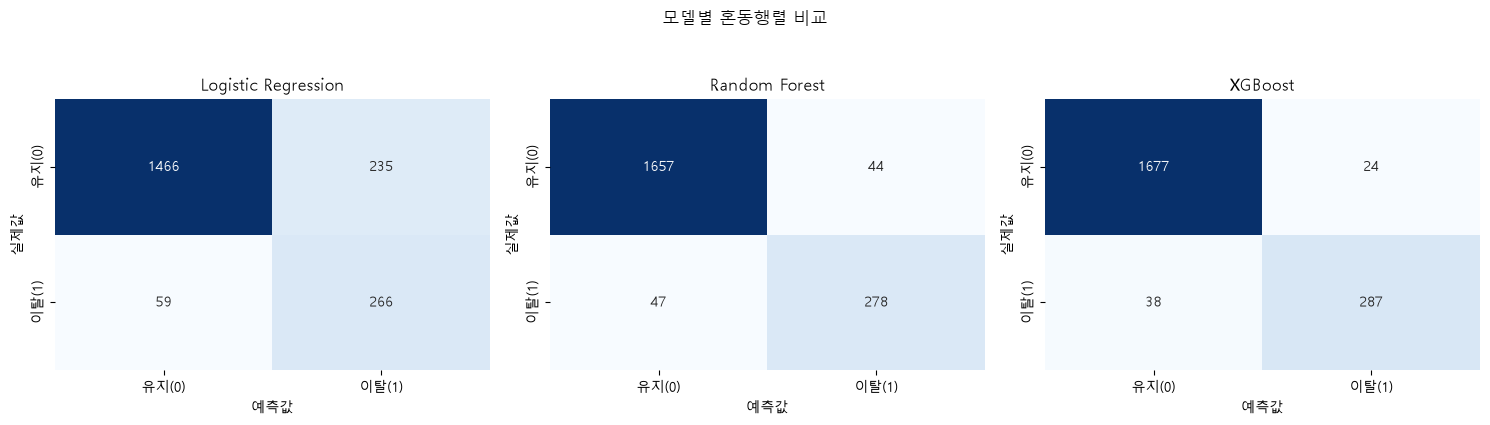

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

models_preds = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["유지(0)", "이탈(1)"],
        yticklabels=["유지(0)", "이탈(1)"],
    )
    ax.set_title(model_name)
    ax.set_xlabel("예측값")
    ax.set_ylabel("실제값")

plt.suptitle("모델별 혼동행렬 비교", y=1.05)
plt.tight_layout()
plt.show()

## 8. 기본 Feature Importance (SHAP 대신 간단 버전)
고도화 단계에서는 SHAP으로 정교하게 분석 예정. 지금은 트리 모델의 기본  
  feature_importances_만 확인  
- 각 변수를 얼마나 많이, 얼마나 효과적으로 활용했는지"를 자동으로 계산해서 저장해두는 속성

In [12]:
importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Total_Trans_Ct              0.241501
Card_Category_Platinum      0.138476
Total_Relationship_Count    0.096500
Total_Revolving_Bal         0.093244
Total_Trans_Amt             0.066091
Total_Ct_Chng_Q4_Q1         0.040233
Months_Inactive_12_mon      0.036605
Contacts_Count_12_mon       0.028250
Total_Amt_Chng_Q4_Q1        0.024936
Customer_Age                0.022335
dtype: float32

# 모델이 예측하는데 영향을 많이 준 컬럼

| 순위 | 변수명 (한글 설명) | 중요도(Importance) |
|---|---|---|
| 1 | Total_Trans_Ct (최근 12개월 총 거래건수) | 0.242 |
| 2 | Card_Category_Platinum (플래티넘 카드 보유 여부) | 0.138 |
| 3 | Total_Relationship_Count (보유 상품·서비스 개수) | 0.097 |
| 4 | Total_Revolving_Bal (리볼빙·이월 잔액) | 0.093 |
| 5 | Total_Trans_Amt (최근 12개월 총 거래금액) | 0.066 |
| 6 | Total_Ct_Chng_Q4_Q1 (1분기 대비 4분기 거래건수 변화율) | 0.040 |
| 7 | Months_Inactive_12_mon (최근 12개월 중 비활성 개월 수) | 0.037 |
| 8 | Contacts_Count_12_mon (최근 12개월 고객센터 문의 횟수) | 0.028 |
| 9 | Total_Amt_Chng_Q4_Q1 (1분기 대비 4분기 거래금액 변화율) | 0.025 |
| 10 | Customer_Age (고객 나이) | 0.022 |

## 요약
- **거래건수(Total_Trans_Ct)가 압도적 1위(24.2%)** — EDA 상관관계 분석 결과와 정확히 일치하는 결과
- 2위가 **플래티넘 카드 보유 여부**라는 점이 흥미로워요 — 앞서 EDA에서 확인했던 "플래티넘 카드 이탈률이 25%로 가장 높다"는 인사이트가 실제 모델에서도 두 번째로 중요한 변수로 확인
- 상위 5개 변수(1~5위)가 전체 중요도의 약 **63.6%**를 차지 — 소수의 핵심 변수가 예측력의 대부분을 차지하는 구조
- 나이(Customer_Age)는 10위지만 중요도가 2.2%로 낮아서, EDA에서 봤던 "나이는 이탈과 거의 무관하다"는 결과와 일관

## 9. 비즈니스 적용 — Baseline 대비 성과(Lift/Gain) 및 우선순위 리스트

실제 카드사 마케팅팀은 모든 고객에게 리텐션 혜택을 줄 수 없으므로,
**"상위 몇 %만 타겟팅해도 실제 이탈자의 몇 %를 잡아낼 수 있는가"**가 핵심 실용 지표  
(XGBoost 이탈확률 기준)

In [14]:
risk_df = pd.DataFrame({
    "고객ID": X_test.index,
    "이탈확률": y_proba_xgb,
    "실제_이탈여부": y_test.values,
}).sort_values("이탈확률", ascending=False).reset_index(drop=True)

total_churners = risk_df["실제_이탈여부"].sum()
print(f"테스트셋 전체 이탈자 수: {total_churners}명\n")

print("상위 K% 타겟팅 시 실제 이탈자 포착률 (무작위 타겟팅 대비 효율):")
for pct in [0.05, 0.10, 0.20, 0.30, 0.50]:
    top_n = int(len(risk_df) * pct)
    captured = risk_df.iloc[:top_n]["실제_이탈여부"].sum()
    capture_rate = captured / total_churners * 100
    lift = capture_rate / (pct * 100)
    print(f"  상위 {int(pct*100):>2}% 타겟팅 → 이탈자 포착률 {capture_rate:5.1f}%  (무작위 대비 {lift:.1f}배 효율)")

테스트셋 전체 이탈자 수: 325명

상위 K% 타겟팅 시 실제 이탈자 포착률 (무작위 타겟팅 대비 효율):
  상위  5% 타겟팅 → 이탈자 포착률  30.8%  (무작위 대비 6.2배 효율)
  상위 10% 타겟팅 → 이탈자 포착률  61.2%  (무작위 대비 6.1배 효율)
  상위 20% 타겟팅 → 이탈자 포착률  94.8%  (무작위 대비 4.7배 효율)
  상위 30% 타겟팅 → 이탈자 포착률  99.4%  (무작위 대비 3.3배 효율)
  상위 50% 타겟팅 → 이탈자 포착률 100.0%  (무작위 대비 2.0배 효율)


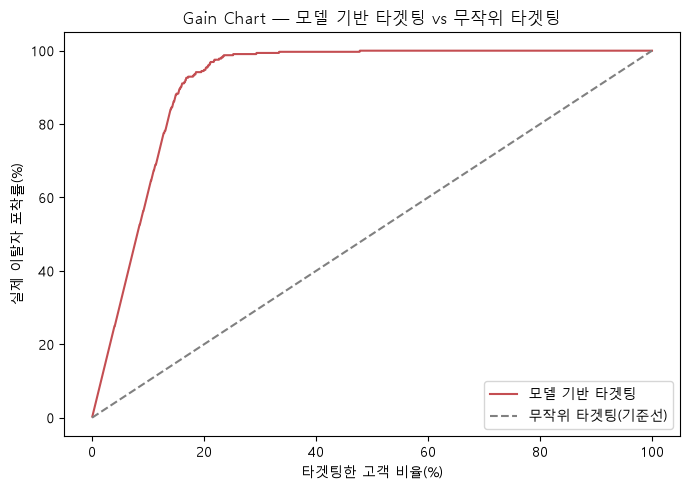

In [15]:
risk_df["누적_이탈자_포착"] = risk_df["실제_이탈여부"].cumsum()
risk_df["누적_비율"] = (risk_df.index + 1) / len(risk_df) * 100
risk_df["누적_포착률"] = risk_df["누적_이탈자_포착"] / total_churners * 100

plt.figure(figsize=(7, 5))
plt.plot(risk_df["누적_비율"], risk_df["누적_포착률"], label="모델 기반 타겟팅", color="#C44E52")
plt.plot([0, 100], [0, 100], linestyle="--", color="gray", label="무작위 타겟팅(기준선)")
plt.xlabel("타겟팅한 고객 비율(%)")
plt.ylabel("실제 이탈자 포착률(%)")
plt.title("Gain Chart — 모델 기반 타겟팅 vs 무작위 타겟팅")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# 1) 고위험군 전체 명단 (이탈확률 95% 이상 - 순위가 아니라 임계값 기준 필터)
high_risk = risk_df[risk_df["이탈확률"] >= 0.95][["고객ID", "이탈확률", "실제_이탈여부"]].copy()
high_risk["이탈확률"] = (high_risk["이탈확률"] * 100).round(1)
high_risk.columns = ["고객ID", "이탈확률(%)", "실제_이탈여부(검증용)"]

print(f"이탈확률 95% 이상 고위험 고객: {len(high_risk)}명")
high_risk.head(10)

이탈확률 95% 이상 고위험 고객: 265명


,고객ID,이탈확률(%),실제_이탈여부(검증용)
0,5925,100.0,1
1,8084,100.0,1
2,7253,100.0,1
3,8186,100.0,1
4,6111,100.0,1
5,8551,100.0,1
6,6244,100.0,1
7,7806,100.0,1
8,8044,100.0,1
9,7082,100.0,1


In [21]:
# 2) 애매한 경계 구간 (40~60%) - 모델도 확신 못하는, 사람의 판단이 더 필요한 영역
# 확실히 이탈할 사람보다, 개입 시 실제로 결과가 바뀔 가능성이 높은 구간이라
# 리텐션 액션의 효과를 검증하기에 더 적합한 대상일 수 있습니다.
uncertain = risk_df[(risk_df["이탈확률"] >= 0.4) & (risk_df["이탈확률"] <= 0.6)][
    ["고객ID", "이탈확률", "실제_이탈여부"]
].copy()
uncertain["이탈확률"] = (uncertain["이탈확률"] * 100).round(1)
uncertain.columns = ["고객ID", "이탈확률(%)", "실제_이탈여부(검증용)"]

print(f"애매한 경계 구간(40~60%) 고객: {len(uncertain)}명")
uncertain.sort_values("이탈확률(%)", ascending=False)

애매한 경계 구간(40~60%) 고객: 13명


,고객ID,이탈확률(%),실제_이탈여부(검증용)
305,6598,59.200001,1
306,5183,58.599998,0
307,134,57.400002,0
308,2015,52.200001,0
309,3167,52.200001,0
310,4088,51.599998,0
311,5478,48.099998,0
312,6625,46.099998,1
313,7943,44.599998,1
314,2793,43.599998,1


## 정리
- Lift/Gain 분석으로 "상위 K% 타겟팅 시 무작위 대비 몇 배 효율적인지"를 정량적으로 제시
- Gain Chart는 이 효율성을 시각적으로 한눈에 보여줌.
- 우선순위 리스트는 실제 상담팀이 바로 활용할 수 있는 컨택 대상 형태로 정리.